In [17]:
# 0. import libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
mpl.rcParams['text.usetex'] = False  # Set to False since LaTeX is not installed; matplotlib's built-in math rendering will still work
import os
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
import datetime
import json
import statsmodels.api as sm
pd.options.mode.chained_assignment = None
from pathlib import Path

In [18]:
# read df_fit
COMBINED_DIR = Path("/Users/xueqingliu/Harvard University Dropbox/Liu Xueqing/ADAPT_MRT/rawdata/_combined")
df_fit = pd.read_csv(COMBINED_DIR / 'df_fit.csv')

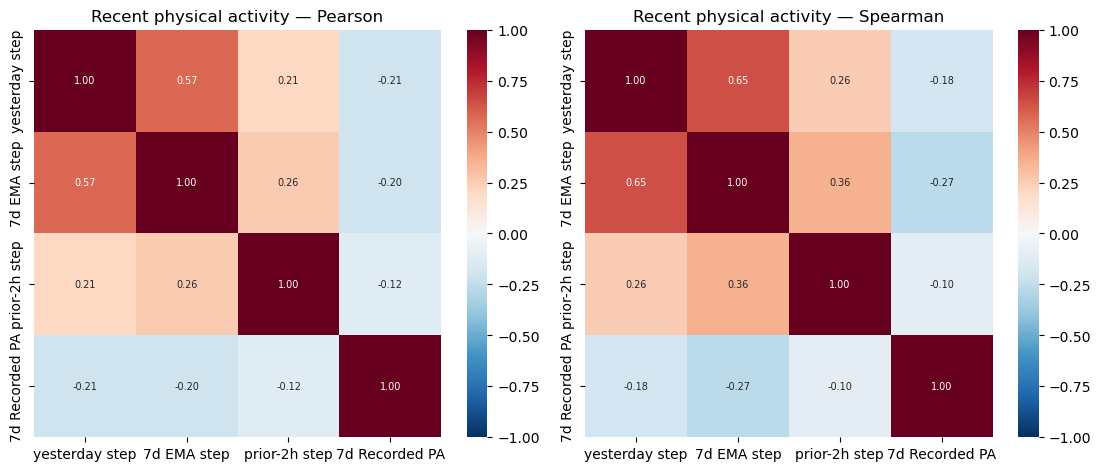

In [21]:
# --- Step-count–related columns (same names as ``2_fit_vanilla_testbed`` / ``df_fit``) ---
# Resolves whichever columns exist in your CSV; drops all-NaN columns.

STEP_COLS = [
    ("YesterdayStepCount_norm", "yesterday step"),
    ("EMA_StepCount_norm", "7d EMA step"),
    ("prior2hour_step_norm", "prior-2h step"),
    ("Previous7DaysRPA", "7d Recorded PA")
]



def _pick_numeric_columns(df, spec_list):
    """Return (list of column names in df, list of short labels)."""
    found, labels = [], []
    for col, lab in spec_list:
        if col in df.columns:
            found.append(col)
            labels.append(lab)
    return found, labels


def _corr_block(df, cols, labels, title):
    if not cols:
        print(f"{title}: no matching columns in df_fit.")
        return
    X = df[cols].apply(pd.to_numeric, errors="coerce")
    X = X.loc[:, X.notna().any(axis=0)]
    if X.shape[1] < 2:
        print(f"{title}: need at least 2 numeric columns; got {list(X.columns)}")
        return
    lab_map = dict(zip(cols, labels))
    short = [lab_map.get(c, c)[:28] for c in X.columns]
    C = X.corr(method="pearson", min_periods=20)
    C_s = X.corr(method="spearman", min_periods=20)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
    for ax, M, name in zip(axes, [C, C_s], ["Pearson", "Spearman"]):
        sns.heatmap(
            M,
            ax=ax,
            cmap="RdBu_r",
            center=0,
            vmin=-1,
            vmax=1,
            square=True,
            annot=True,
            fmt=".2f",
            annot_kws={"size": 7},
            xticklabels=short,
            yticklabels=short,
        )
        ax.set_title(f"{title} — {name}")
    plt.show()

    # Flag strong linear redundancy (|r| > 0.85), lower triangle
#     print(f"\n{title} — |Pearson r| > 0.85 (excluding diagonal)")
#     for i in range(C.shape[0]):
#         for j in range(i):
#             v = C.iloc[i, j]
#             if np.isfinite(v) and abs(v) > 0.85:
#                 print(f"  {C.columns[i]}  vs  {C.columns[j]}:  r = {v:.3f}")

#     # Pairwise scatter for a compact subset (first up to 4 columns)
#     k = min(4, X.shape[1])
#     sub = X.iloc[:, :k].dropna()
#     if len(sub) > 5:
#         g = sns.pairplot(sub, corner=True, plot_kws={"alpha": 0.25, "s": 8}, diag_kind="kde")
#         g.fig.suptitle(f"{title} — pairwise (first {k} columns)", y=1.02)
#         plt.show()


cols_s, lab_s = _pick_numeric_columns(df_fit, STEP_COLS)
_corr_block(df_fit, cols_s, lab_s, "Recent physical activity")


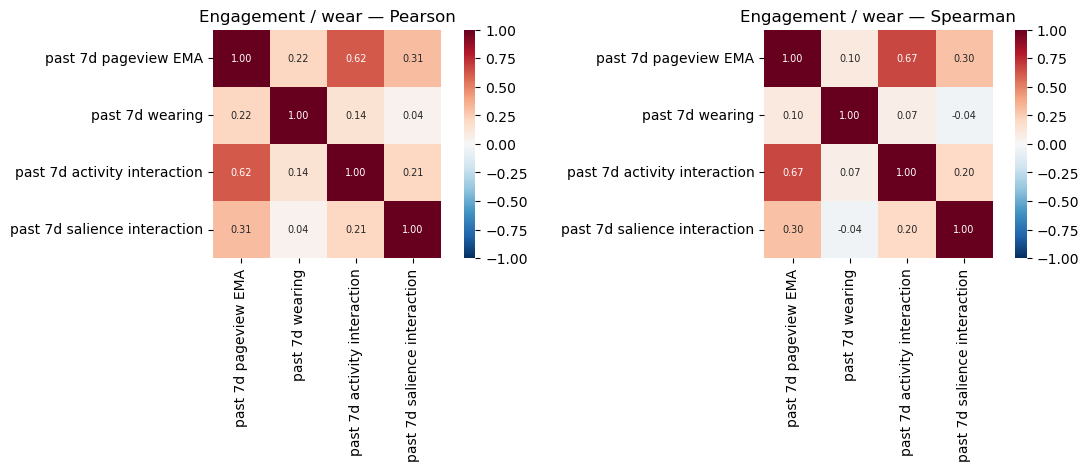

In [20]:
# --- Engagement / wear proxies (names aligned with ``1.5_standardization`` / ``2_fit_vanilla_testbed``) ---

ENG_COLS = [
    ("Past7DaysPageviewEMA_norm", "past 7d pageview EMA"),
    ("past7days_daywearing", "past 7d wearing"),
    ("Interacted_7d_walk", "past 7d activity interaction"),
    ("Interacted_7d_salience", "past 7d salience interaction"),
]


cols_e, lab_e = _pick_numeric_columns(df_fit, ENG_COLS)
_corr_block(df_fit, cols_e, lab_e, "Engagement / wear")
